In [10]:
import igraph as ig
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import IntSlider, interact
from tqdm.notebook import tqdm

rng = np.random.default_rng()

In [11]:
def find(ptr, i):
    while ptr[i] != None:
        i = ptr[i]
    return i


def newman_ziff(graph, order, use_tqdm=True):
    neighbours = graph.get_adjlist()
    n = graph.vcount()
    parent = np.full(n, None)
    size = np.zeros(n, dtype="int64")
    data = {"lcc": np.zeros(n), "av_size": np.zeros(n), "n_clusters": np.zeros(n)}
    lcc_size = 0
    n_clusters = 0
    if use_tqdm:
        wrapper = tqdm(range(n))
    else:
        wrapper = range(n)
    for idx in wrapper:
        root = order[idx]
        size[root] = 1
        n_clusters += 1
        for near in neighbours[root]:
            if size[near]:
                near = find(parent, near)
                if near != root:
                    n_clusters -= 1
                    if size[root] < size[near]:
                        size[near] += size[root]
                        parent[root] = near
                        root = near
                    else:
                        size[root] += size[near]
                        parent[near] = root

        if lcc_size < size[root]:
            lcc_size = size[root]

        data["av_size"][idx] = (idx + 1 - lcc_size) / n_clusters
        data["n_clusters"][idx] = n_clusters
        data["lcc"][idx] = lcc_size
    return data

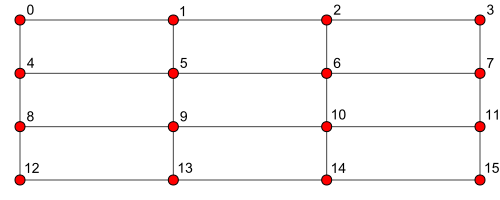

In [12]:
g = ig.Graph.Lattice([4, 4], circular=False)
ig.plot(
    g,
    layout="grid",
    bbox=(500, 200),
    vertex_size=10,
    vertex_label=g.vs.indices,
    vertex_label_dist=2,
    vertex_label_angle=np.pi / 4,
)

In [13]:
order = rng.permutation(g.vcount())
data = newman_ziff(g, order)
order

  0%|          | 0/16 [00:00<?, ?it/s]

array([15, 14,  1,  3,  0,  4,  9, 13,  6,  8,  2,  5, 10, 12,  7, 11])

In [16]:
print(data["n_clusters"])
print(data["av_size"])
# print((np.arange(1, g.vcount()+1) - data["lcc"]) / data["n_clusters"])

[1. 1. 2. 3. 3. 3. 4. 3. 4. 3. 1. 1. 1. 1. 1. 1.]
[0.         0.         0.5        0.66666667 1.         1.
 1.         1.33333333 1.25       0.66666667 0.         0.
 0.         0.         0.         0.        ]


In [17]:
def plotter(frame):
    colored = order[:frame]
    colors = ["blue" if id in colored else "red" for id in range(g.vcount())]
    print(colors)
    fig, ax = plt.subplots(figsize=(10, 5))
    ig.plot(
        g,
        target=ax,
        layout="grid",
        vertex_size=0.4,
        vertex_color=colors,
        vertex_label=g.vs.indices
    )

interact(plotter, frame=IntSlider(1, 1, len(order)))

interactive(children=(IntSlider(value=1, description='frame', max=16, min=1), Output()), _dom_classes=('widget…

<function __main__.plotter(frame)>